In [1]:
"""
Try whole pipeline (Glasso -> Cluster -> Cvxpy opt -> LRT)

Try it on MV-Normal simulated data
""";

In [2]:
import numpy as np
from numpy.linalg import inv as inv
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2
from scipy.stats import multivariate_normal
from scipy.optimize import minimize

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection
from statsmodels.tsa.seasonal import STL

import cvxpy as cp

%matplotlib inline

# fix random seed
np.random.seed(39)

import warnings
warnings.filterwarnings('ignore')  # <- remember to comment this if something breaks and you get confused

In [3]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

In [4]:
def generate_matrices_orthogonal(prec_coeffs=None, M=2, dim=4):
    H_s = []
    if not prec_coeffs:
        prec_coeffs = np.random.rand(M)
    precision = np.zeros((dim, dim))
    H_s_stacked = np.zeros((dim**2, M))
    mat = make_spd_matrix(dim)
    indxes = np.random.choice(np.arange(dim), (M, dim//M), replace=False)
    for i in range(M):
        A = np.zeros((dim, dim))
        for idx in indxes[i]:
            for idx2 in indxes[i]:
                A[idx, idx2] = mat[idx, idx2]
        H_s.append(A)
        precision += prec_coeffs[i]*A
        H_s_stacked[:, i] = A.flatten()
    H_s = np.array(H_s)
    
    # ensure basis matrices are linearly independent
    assert np.linalg.matrix_rank(H_s_stacked) == M, "Not Linearly Independent basis matrices"
    
    # ensure it's actually symmetric
    # minimal modification on scale of 1e-15
    precision_corrected = (precision + precision.T)/2
    
    return H_s, precision_corrected, prec_coeffs

def collect_precision_matrix(H_s, prec_coeffs):
    precision = (prec_coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    
    return precision

def sim_changepoint_mv_normal_orthogonal(M=2, dim=4, N=500):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    prec_coeffs_two = prec_coeffs_one.copy()
    prec_coeffs_two[0] += 0.8
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    
    return H_s, data_total

def sim_changepoint_mv_normal_orthogonal_mult_coeff(M=2, dim=4, N=500, num_coeffs_change=1):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    assert num_coeffs_change <= M, "Cannot change more coefficients than exist"
    
    # multiple coeffs to change - sample them randomly
    to_change_coeffs = np.random.choice(np.arange(M), num_coeffs_change, replace=False)
    prec_coeffs_two = prec_coeffs_one.copy()
    for i in range(num_coeffs_change):
        prec_coeffs_two[to_change_coeffs[i]] += np.random.uniform(0.1, 0.3, 1)[0]
        
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    print("Precision Coefficients Pre-Changepoint: ", prec_coeffs_one)
    print("Precision Coefficients Post-Changepoint: ", prec_coeffs_two)
    
    return H_s, data_total

def sim_data(covar, dim, N=1000):
    assert is_symmetric(covar), is_pos_def(covar)
    data_sim = np.random.multivariate_normal(np.zeros(dim), covar, N).T
    data_sim = data_sim - data_sim.mean()
    C = np.cov(data_sim)
    
    return data_sim, C

In [5]:
def sim_changepoint_mv_normal_no_decomp(dim, N, num_coeffs_change=1):
    C_one = make_spd_matrix(dim)
    data_one = np.random.multivariate_normal(np.zeros(dim), C_one, N)
    
    rand_i_j = np.random.choice(np.arange(dim), 2, replace=False)
    i, j = rand_i_j[0], rand_i_j[1]
    C_two = C_one.copy()
    val = C_one[i,j]
    val += 0.8
    C_two[i, j] = val
    C_two[j, i] = val
    
    # keep it pos_def
    adjustment = np.abs(np.linalg.eig(C_two)[0].min()) + 1e-12
    C_two += np.eye(dim)*adjustment
    
    data_two = np.random.multivariate_normal(np.zeros(dim), C_two, N)
    data_total = np.concatenate((data_one, data_two), axis=0)
    
    assert is_pos_def(C_one)
    assert is_symmetric(C_one)
    assert is_pos_def(C_two)
    assert is_symmetric(C_two)
    
    return data_total.T

In [50]:
M = 2
dim = 16
N = 1000
_, data_total = sim_changepoint_mv_normal_orthogonal_mult_coeff(M=M, dim=dim, N=N, num_coeffs_change=1)
#data_total = sim_changepoint_mv_normal_no_decomp(dim=dim, N=N)
# transpose for GLasso
data_total = data_total.T

Precision Coefficients Pre-Changepoint:  [0.47386609 0.29171138]
Precision Coefficients Post-Changepoint:  [0.47386609 0.40669762]


In [51]:
data_total.shape

(2000, 16)

In [52]:
lam = 1e-1

ret = GraphicalLasso(max_iter=100, alpha=lam, tol=1e-5, verbose=False).fit(data_total)

precision = ret.precision_.copy()
clust_dist_mat = np.abs(precision)
np.fill_diagonal(clust_dist_mat, 0.0)
clust_dist_mat = clust_dist_mat.max() - clust_dist_mat
np.fill_diagonal(clust_dist_mat, 0.0)

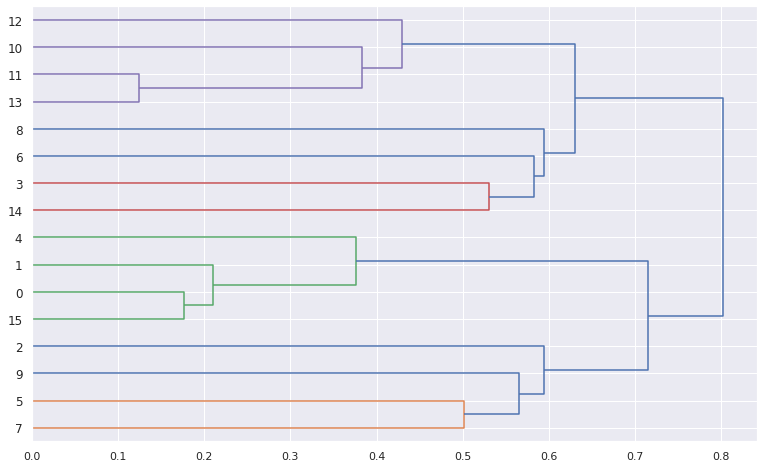

In [53]:
pairwise_distances = sch.distance.pdist(clust_dist_mat)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(13, 8))
dendrogram(
            Z,
            orientation='right',
            labels=np.arange(data_total.shape[1]),
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [54]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=2).squeeze()
cutree1

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [55]:
prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2].copy() # set i,j entry to be the entry from precision matrix for given cluster
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)
basis_matrices.shape

(2, 16, 16)

In [56]:
leftover_basis_matrix = precision - basis_matrices.sum(axis=0)

In [57]:
basis_matrices_full = np.concatenate((basis_matrices, np.expand_dims(leftover_basis_matrix, 0)), 0)
basis_matrices_full.sum(axis=0) == ret.precision_

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  Tru

In [58]:
basis_matrices.sum(axis=0) == ret.precision_

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True, False,  True,  True,
         True, False,  True, False,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True, False,  True, False,
         True,  True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True, False,  True, False,
         True,  True, False,  True,  True,  True,  True],
       [ True, False,  True,  True, False, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True, False,
         True, False,  Tru

In [59]:
assert is_pos_def(basis_matrices_full.sum(axis=0)), "Not PosDef"
assert is_pos_def(basis_matrices.sum(axis=0)), "Not PosDef"
for mat in basis_matrices_full:
    assert is_symmetric(mat), "Not Symmetric"

In [60]:
H_s = basis_matrices_full.copy()
#H_s = basis_matrices.copy()
M = H_s.shape[0]
dim = H_s.shape[-1]
window_size = 100
# transpose it back
data_full = data_total.T
print(M, dim)

3 16


In [61]:
data_full.shape

(16, 2000)

In [62]:
C_full = np.cov(data_full, bias=True)
C_full.shape

(16, 16)

In [63]:
alphas = cp.Variable(shape=(M, ))
psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C_full) - lam*l1_penalty)
constr1 = (psi_hat >> 0)
constr2 = (psi_hat == psi_hat.T)
constraints = [constr1, constr2]
problem = cp.Problem(objective, constraints)
problem.solve()
if problem.status != cp.OPTIMAL:
    raise Exception('CVXPY Error')
alphas.value

array([1.00000167, 1.00000271, 1.00023069])

In [87]:
def likelihood_ratio_test(likelihood_null, likelihood_alternative, dof):
    delta_d = -2*(likelihood_null-likelihood_alternative)
    
    return delta_d, chi2.pdf(delta_d, dof)


def optimize_coeffs(H_s, C, lam=1e-2):
    M = H_s.shape[0]
    alphas = cp.Variable(shape=(H_s.shape[0], ))
    psi_hat = sum([alphas[i]*H_s[i] for i in range(M)])
    l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
    objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C) - lam*l1_penalty)
    constr1 = (psi_hat >> 0)
    constr2 = (psi_hat == psi_hat.T)
    problem = cp.Problem(objective, constraints)
    problem.solve()
    if problem.status != cp.OPTIMAL:
        raise Exception('CVXPY Error')
        
    return alphas.value

def optimize_single_coeff(alphas, H_s, C, coeff_idx=0, lam=1e-2):
    M = H_s.shape[0]
    single_alpha = cp.Variable()
    psi_hat = np.zeros(C.shape)
    for i in range(M):
        if i == coeff_idx:
            psi_hat += single_alpha*H_s[i]
        else:
            psi_hat += alphas[i]*H_s[i]
    l1_penalty = sum([cp.abs(psi_hat[i, j])
                  for i in range(dim)
                  for j in range(dim) if i != j])
    objective = cp.Maximize(cp.log_det(psi_hat) - cp.trace(psi_hat@C) - lam*l1_penalty)
    constr1 = (psi_hat >> 0)
    constr2 = (psi_hat == psi_hat.T)
    problem = cp.Problem(objective, constraints)
    problem.solve()
    if problem.status != cp.OPTIMAL:
        raise Exception('CVXPY Error')
    
    new_alphas = alphas.copy()
    new_alphas[coeff_idx] = single_alpha.value
    return new_alphas

# this is maximized likelihood, not NLL
def lasso_likelihood(alphas, H_s, C, lam=1e-2, include_l1=False):
    psi_hat = sum([alphas[i]*H_s[i] for i in range(H_s.shape[0])])
    l1_penalty = sum([np.abs(psi_hat[i, j])
                  for i in range(C.shape[0])
                  for j in range(C.shape[1]) if i != j])
    
    if include_l1:
        return np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - lam*l1_penalty
    
    else:
        return np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C)
    
def full_likelihood(alphas, H_s, C, N, lam=1e-2, include_l1=False):
    P = C.shape[0]
    psi_hat = sum([alphas[i]*H_s[i] for i in range(H_s.shape[0])])
    l1_penalty = sum([np.abs(psi_hat[i, j])
                  for i in range(C.shape[0])
                  for j in range(C.shape[1]) if i != j])
    
    if include_l1:
        likelihood = np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - lam*l1_penalty - P*np.log(2*np.pi)
        return likelihood*(N/2)
    
    else:
        likelihood = np.log(np.linalg.det(psi_hat)) - np.trace(psi_hat@C) - P*np.log(2*np.pi)
        return likelihood*(N/2)
    

###################
def LRT_all_coeffs(data_total, M, dim, H_s, window_size=500, lam=1e-2, step_size=1):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, step_size)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)

        coeffs_hat_one = optimize_coeffs(H_s, C_one, lam=lam)
        coeffs_hat_two = optimize_coeffs(H_s, C_two, lam=lam)
        coeffs_hat_total = optimize_coeffs(H_s, C_full, lam=lam)
        null_first = lasso_likelihood(coeffs_hat_total, H_s, C_one, lam=lam)
        null_second = lasso_likelihood(coeffs_hat_total, H_s, C_two, lam=lam)
        null_likelihood = null_first + null_second
        alt_likelihood_one = lasso_likelihood(coeffs_hat_one, H_s, C_one, lam=lam)
        alt_likelihood_two = lasso_likelihood(coeffs_hat_two, H_s, C_two, lam=lam)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals


def LRT_all_coeffs_full_likelihood(data_total, M, dim, H_s, window_size=500, lam=1e-2, step_size=1):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, step_size)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)

        coeffs_hat_one = optimize_coeffs(H_s, C_one, lam=lam)
        coeffs_hat_two = optimize_coeffs(H_s, C_two, lam=lam)
        coeffs_hat_total = optimize_coeffs(H_s, C_full, lam=lam)
        null_first = full_likelihood(coeffs_hat_total, H_s, C_one, N=data_one.shape[1], 
                                     lam=lam, include_l1=False)
        null_second = full_likelihood(coeffs_hat_total, H_s, C_two, N=data_two.shape[1], 
                                     lam=lam, include_l1=False)
        null_likelihood = null_first + null_second
        alt_likelihood_one = full_likelihood(coeffs_hat_one, H_s, C_one, N=data_one.shape[1], 
                                     lam=lam, include_l1=False)
        alt_likelihood_two = full_likelihood(coeffs_hat_two, H_s, C_two, N=data_two.shape[1], 
                                     lam=lam, include_l1=False)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals


def LRT_individual_coeffs_full_likelihood(data_total, M, dim, H_s, window_size=500, lam=1e-2, step_size=1):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, step_size)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)
        coeffs_hat_total = optimize_coeffs(H_s, C_full, lam=lam)
        # null likelihood
        null_first = full_likelihood(coeffs_hat_total, H_s, C_one, N=data_one.shape[1], 
                                     lam=lam, include_l1=True)
        null_second = full_likelihood(coeffs_hat_total, H_s, C_two, N=data_two.shape[1], 
                                     lam=lam, include_l1=True)
        null_likelihood = null_first + null_second
        
        test_stats_m = []
        p_vals_m = []
        # iterate over each coefficient
        for i in range(M):
            alpha_i_change_pre = optimize_single_coeff(coeffs_hat_total, H_s, C_one, coeff_idx=i,
                                                       lam=lam)
            alpha_i_change_post = optimize_single_coeff(coeffs_hat_total, H_s, C_two, coeff_idx=i,
                                                        lam=lam)
            # likelihood on pre data, alpha_one change
            alt_likelihood_alpha_i_pre = full_likelihood(alpha_i_change_pre, H_s, C_one, N=data_one.shape[1], 
                                                         lam=lam, include_l1=True)
            # likelihood on post data, alpha_one change
            alt_likelihood_alpha_i_post = full_likelihood(alpha_i_change_post, H_s, C_two, N=data_two.shape[1], 
                                                          lam=lam, include_l1=True)
            # total likelihood alt first coeff
            alt_likelihood_alpha_i = alt_likelihood_alpha_i_pre + alt_likelihood_alpha_i_post
            
            test_stat_i, p_val_i = first_test = likelihood_ratio_test(null_likelihood, 
                                                                      alt_likelihood_alpha_i, 2)
            test_stats_m.append(test_stat_i)
            p_vals_m.append(p_val_i)
            
        lrt_vals.append(test_stats_m)
        p_vals.append(p_vals_m)
    
    # return arrays with shape (num_tests, M)
    return np.array(lrt_vals), np.array(p_vals)

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [88]:
# sanity checking the single coeff optim

alphas = optimize_coeffs(H_s, C_full, lam=lam)
C_one = np.cov(data_full[:, 0:1000], bias=True)
C_two = np.cov(data_full[:, 1000:], bias=True)
new_alphas_pre = optimize_single_coeff(alphas, H_s, C_one, coeff_idx=1, lam=lam)
new_alphas_post = optimize_single_coeff(alphas, H_s, C_two, coeff_idx=1, lam=lam)
alphas, new_alphas_pre, new_alphas_post

(array([1.00000226, 0.99999924, 1.00015713]),
 array([1.00000226, 0.86764653, 1.00015713]),
 array([1.00000226, 1.1822284 , 1.00015713]))

In [66]:
data_full.shape

(16, 2000)

In [67]:
# lrt_vals, p_vals = LRT_all_coeffs(data_full, M=M, dim=dim, H_s=H_s, window_size=window_size, lam=lam, 
#                                   step_size=20)
lrt_vals, p_vals = LRT_all_coeffs_full_likelihood(data_full, M=M, dim=dim, H_s=H_s, 
                                                  window_size=window_size, lam=lam, step_size=50)

  0%|          | 0/36 [00:00<?, ?it/s]

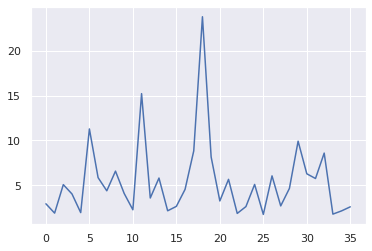

In [68]:
plt.plot(lrt_vals)

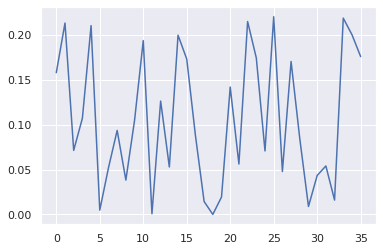

In [69]:
plt.plot(p_vals)

In [89]:
lrt_vals, p_vals = LRT_individual_coeffs_full_likelihood(data_full, M=M, dim=dim, H_s=H_s, 
                                                         window_size=window_size, lam=lam, step_size=50)

  0%|          | 0/36 [00:00<?, ?it/s]

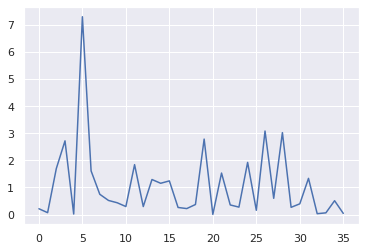

In [90]:
plt.plot(lrt_vals[:, 0])

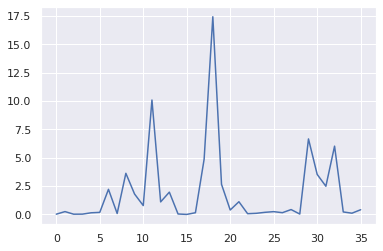

In [91]:
plt.plot(lrt_vals[:, 1])

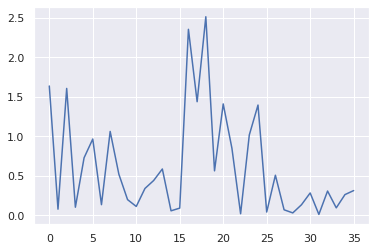

In [92]:
plt.plot(lrt_vals[:, 2])

In [93]:
corrected_p_vals = apply_fdr_correction(p_vals)

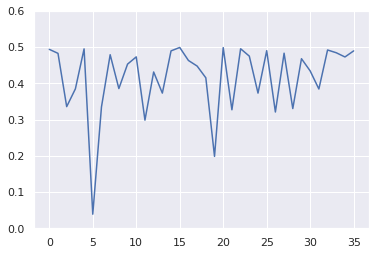

In [101]:
plt.plot(corrected_p_vals[:, 0])
plt.ylim(0.0, 0.6);

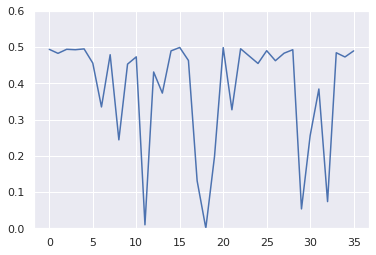

In [103]:
plt.plot(corrected_p_vals[:, 1])
plt.ylim(0.0, 0.6);

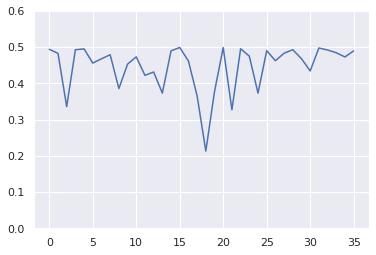

In [104]:
plt.plot(corrected_p_vals[:, 2])
plt.ylim(0.0, 0.6);